<a href="https://colab.research.google.com/github/rahilkhan-acadmic/APAIML-GradedMiniProject/blob/develop/capstone/03_claim_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Model B — Claim Outcome Classification
### Business Purpose: Predict whether an insurance claim will be Paid, Pending, or Rejected before submission.

  * Define the target variable as claim_status.
  * Engineer financial and operational predictor features.
  * Perform a time-based train and test split.
  * Train baseline and advanced classification models.
  * Analyze class imbalance and mitigation strategy.


In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

In [68]:
# Upload file to google.colab
import io
from google.colab import files, drive

drive.mount('/content/drive')

# comment this code, if files already uploaded.
# uploaded = files.upload()

# Load and read patients, visits & billing csv
patients_df = pd.read_csv('/content/drive/MyDrive/files/capstone/patients.csv')
# patients_df.head()

visits_df = pd.read_csv('/content/drive/MyDrive/files/capstone/visits.csv')
# visits_df.head()

billing_df = pd.read_csv('/content/drive/MyDrive/files/capstone/billing.csv')
# billing_df.head()

# Merge dataframe
df_merged = pd.merge(patients_df, visits_df, on='patient_id', how = 'inner')
df_merged = pd.merge(df_merged, billing_df, on='visit_id', how = 'inner')
df_merged.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,patient_id,age,gender,city,insurance_provider,chronic_flag,registration_date,visit_id,visit_date,department,visit_type,length_of_stay_hours,risk_score,doctor_id,bill_id,billed_amount,approved_amount,claim_status,payment_days,billing_date
0,1,53,M,Hyderabad,SecureLife,0,2025-05-14,4327,2025-10-15,General,ICU,6.39,High,162,4327,26322.05,13938.52,Pending,NaN,2025-11-29
1,1,53,M,Hyderabad,SecureLife,0,2025-05-14,5395,2025-09-21,Orthopedics,OPD,39.12,Low,181,5395,13258.56,0.00,Rejected,3.0,2025-08-15
2,1,53,M,Hyderabad,SecureLife,0,2025-05-14,9032,2025-02-09,Cardiology,OPD,19.57,Medium,121,9032,26555.09,26555.09,Paid,4.0,2025-12-31
3,1,53,M,Hyderabad,SecureLife,0,2025-05-14,9506,2025-10-09,Neurology,ER,30.32,Medium,135,9506,11583.16,8065.34,Pending,6.0,2025-01-30
4,1,53,M,Hyderabad,SecureLife,0,2025-05-14,10868,2025-07-07,ICU,ER,30.07,High,164,10868,9049.72,9049.72,Paid,19.0,2025-02-26


### Define the target variable as claim_status.

In [69]:
# Define the target variable as claim_status.
df_target = df_merged[['claim_status']]
display(df_target.head().reset_index())


,index,claim_status
0,0,Pending
1,1,Rejected
2,2,Paid
3,3,Pending
4,4,Paid


### Engineer financial and operational predictor features.

In [70]:
# Engineer financial and operational predictor features.

# Convert Date Columns to datetime objects.
df_merged['registration_date'] = pd.to_datetime(df_merged['registration_date'])
df_merged['visit_date'] = pd.to_datetime(df_merged['visit_date'])
df_merged['billing_date'] = pd.to_datetime(df_merged['billing_date'])

# Display the data types to verify the conversion
print(df_merged[['registration_date', 'visit_date', 'billing_date']].dtypes)

# Sorting df_merged based on patient_id, registration_date, visit_date, billing_date
df_merged = df_merged.sort_values(by=['patient_id', 'registration_date', 'visit_date', 'billing_date'])

display(df_merged)

registration_date    datetime64[ns]
visit_date           datetime64[ns]
billing_date         datetime64[ns]
dtype: object


,patient_id,age,gender,city,insurance_provider,chronic_flag,registration_date,visit_id,visit_date,department,visit_type,length_of_stay_hours,risk_score,doctor_id,bill_id,billed_amount,approved_amount,claim_status,payment_days,billing_date
2,1,53,M,Hyderabad,SecureLife,0,2025-05-14,9032,2025-02-09,Cardiology,OPD,19.57,Medium,121,9032,26555.09,26555.09,Paid,4.0,2025-12-31
5,1,53,M,Hyderabad,SecureLife,0,2025-05-14,23957,2025-07-05,Orthopedics,ER,7.63,Medium,178,23957,38801.14,38801.14,Paid,1.0,2025-09-27
4,1,53,M,Hyderabad,SecureLife,0,2025-05-14,10868,2025-07-07,ICU,ER,30.07,High,164,10868,9049.72,9049.72,Paid,19.0,2025-02-26
1,1,53,M,Hyderabad,SecureLife,0,2025-05-14,5395,2025-09-21,Orthopedics,OPD,39.12,Low,181,5395,13258.56,0.00,Rejected,3.0,2025-08-15
3,1,53,M,Hyderabad,SecureLife,0,2025-05-14,9506,2025-10-09,Neurology,ER,30.32,Medium,135,9506,11583.16,8065.34,Pending,6.0,2025-01-30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24998,5000,29,M,Chennai,MediCareX,0,2025-07-29,23879,2025-02-17,General,ICU,13.71,Low,162,23879,11029.37,8322.08,Pending,23.0,2026-01-18
24995,5000,29,M,Chennai,MediCareX,0,2025-07-29,14756,2025-03-24,ICU,ER,8.52,Low,123,14756,29171.44,21865.80,Pending,1.0,2025-03-30
24999,5000,29,M,Chennai,MediCareX,0,2025-07-29,24588,2025-06-17,Neurology,ICU,22.93,Medium,165,24588,19004.72,16184.24,Pending,23.0,2025-06-12
24997,5000,29,M,Chennai,MediCareX,0,2025-07-29,20692,2025-11-20,Orthopedics,ER,33.39,Low,167,20692,13825.80,13825.80,Paid,7.0,2025-08-14


In [71]:
# Engineering Financial Features

# 1. Create 'amount_difference'
df_merged['amount_difference'] = df_merged['billed_amount'] - df_merged['approved_amount']

# 2. Create 'approval_ratio', handling division by zero
df_merged['approval_ratio'] = np.where(
    df_merged['billed_amount'] != 0,
    df_merged['approved_amount'] / df_merged['billed_amount'],
    0  # Assign 0 if billed_amount is zero to avoid division by zero
)

# Display the head of df_merged with new columns to verify
print(df_merged[['billed_amount', 'approved_amount', 'amount_difference', 'approval_ratio']].head())

   billed_amount  approved_amount  amount_difference  approval_ratio
2       26555.09         26555.09               0.00        1.000000
5       38801.14         38801.14               0.00        1.000000
4        9049.72          9049.72               0.00        1.000000
1       13258.56             0.00           13258.56        0.000000
3       11583.16          8065.34            3517.82        0.696299


In [72]:
# Engineering Time-Based Operational Features
df_merged['days_since_registration_to_visit'] = (df_merged['visit_date'] - df_merged['registration_date']).dt.days
df_merged['days_between_visit_and_billing'] = (df_merged['billing_date'] - df_merged['visit_date']).dt.days
df_merged['length_of_stay_days'] = df_merged['length_of_stay_hours'] / 24

# Display the head of df_merged with new columns to verify
display(df_merged[['registration_date', 'visit_date', 'billing_date', 'days_since_registration_to_visit', 'days_between_visit_and_billing', 'length_of_stay_hours', 'length_of_stay_days']].head())

# Handling days_between_visit_and_billing with -ve value.
# This could be due to data inconsistency or pre-approval case.
# For such cases -ve values are replaced with 0
df_merged['days_between_visit_and_billing'] = df_merged['days_between_visit_and_billing'].apply(lambda x: max(0, x))

print("df_merged with corrected 'days_between_visit_and_billing' (negative values set to 0):")
display(df_merged[['patient_id', 'visit_date', 'billing_date', 'days_between_visit_and_billing']].head())

,registration_date,visit_date,billing_date,days_since_registration_to_visit,days_between_visit_and_billing,length_of_stay_hours,length_of_stay_days
2,2025-05-14,2025-02-09,2025-12-31,-94,325,19.57,0.815417
5,2025-05-14,2025-07-05,2025-09-27,52,84,7.63,0.317917
4,2025-05-14,2025-07-07,2025-02-26,54,-131,30.07,1.252917
1,2025-05-14,2025-09-21,2025-08-15,130,-37,39.12,1.630000
3,2025-05-14,2025-10-09,2025-01-30,148,-252,30.32,1.263333


df_merged with corrected 'days_between_visit_and_billing' (negative values set to 0):


,patient_id,visit_date,billing_date,days_between_visit_and_billing
2,1,2025-02-09,2025-12-31,325
5,1,2025-07-05,2025-09-27,84
4,1,2025-07-07,2025-02-26,0
1,1,2025-09-21,2025-08-15,0
3,1,2025-10-09,2025-01-30,0


In [73]:
# One-Hot Encoding for Categorical Features
categorical_cols = ['gender', 'city', 'insurance_provider', 'department', 'visit_type']

# Apply one-hot encoding
df_encoded = pd.get_dummies(df_merged[categorical_cols], columns=categorical_cols, drop_first=True)

# Select and justify feature set based on business relevance.
# 'patient_id' not dropped as it will be used for grouping and sorting later
df_features = df_merged.drop(columns=['risk_score', 'visit_id','bill_id', 'doctor_id'])
display(df_features.columns)

# Drop original categorical columns from df_features, ignoring errors if columns are already absent
df_features = df_features.drop(columns=categorical_cols, errors='ignore')
# Concatenate the one-hot encoded features with df_features
df_features = pd.concat([df_features, df_encoded], axis=1)

print("Shape of df_features after one-hot encoding:", df_features.shape)
print("Head of df_features after one-hot encoding:")
display(df_features.head())


Index(['patient_id', 'age', 'gender', 'city', 'insurance_provider',
       'chronic_flag', 'registration_date', 'visit_date', 'department',
       'visit_type', 'length_of_stay_hours', 'billed_amount',
       'approved_amount', 'claim_status', 'payment_days', 'billing_date',
       'amount_difference', 'approval_ratio',
       'days_since_registration_to_visit', 'days_between_visit_and_billing',
       'length_of_stay_days'],
      dtype='object')

Shape of df_features after one-hot encoding: (25000, 32)
Head of df_features after one-hot encoding:


,patient_id,age,chronic_flag,registration_date,visit_date,length_of_stay_hours,billed_amount,approved_amount,claim_status,payment_days,...,insurance_provider_HealthPlus,insurance_provider_MediCareX,insurance_provider_SecureLife,department_ER,department_General,department_ICU,department_Neurology,department_Orthopedics,visit_type_ICU,visit_type_OPD
2,1,53,0,2025-05-14,2025-02-09,19.57,26555.09,26555.09,Paid,4.0,...,False,False,True,False,False,False,False,False,False,True
5,1,53,0,2025-05-14,2025-07-05,7.63,38801.14,38801.14,Paid,1.0,...,False,False,True,False,False,False,False,True,False,False
4,1,53,0,2025-05-14,2025-07-07,30.07,9049.72,9049.72,Paid,19.0,...,False,False,True,False,False,True,False,False,False,False
1,1,53,0,2025-05-14,2025-09-21,39.12,13258.56,0.00,Rejected,3.0,...,False,False,True,False,False,False,False,True,False,True
3,1,53,0,2025-05-14,2025-10-09,30.32,11583.16,8065.34,Pending,6.0,...,False,False,True,False,False,False,True,False,False,False


In [74]:
# apply data engineering on df_features
# Create a fresh df_features DataFrame by explicitly selecting desired columns
# Start with numerical columns that are definitely needed and not redundant from df_merged
initial_numerical_cols = [
    'patient_id', 'age', 'chronic_flag',
    'billed_amount', 'approved_amount', 'payment_days'
]

df_features = df_merged[initial_numerical_cols].copy()

# Add the engineered financial and operational features that are already calculated in df_merged
engineered_cols_from_merged = [
    'amount_difference', 'approval_ratio',
    'days_between_visit_and_billing', 'length_of_stay_days'
]

display(df_features.columns)

for col in engineered_cols_from_merged:
    if col in df_merged.columns and col not in df_features.columns:
        df_features[col] = df_merged[col]

# Concatenate the one-hot encoded categorical features
df_features = pd.concat([df_features, df_encoded], axis=1)

# Calculate days between visits for each patient and then the average
df_merged_sorted = df_merged.sort_values(by=['patient_id', 'visit_date'])
df_merged_sorted['days_between_visits'] = df_merged_sorted.groupby('patient_id')['visit_date'].diff().dt.days
df_avg_days_between_visits = df_merged_sorted.groupby('patient_id')['days_between_visits'].mean().reset_index()
df_avg_days_between_visits.rename(columns={'days_between_visits': 'avg_days_between_visits'}, inplace=True)

# Merge this new feature into df_features
df_features = pd.merge(df_features, df_avg_days_between_visits, on='patient_id', how='left')

# Final clean-up: Remove the target variable and the less relevant time feature
columns_to_drop_final = [
    'claim_status', # Target variable, must not be in features
    'days_since_registration_to_visit' # Replaced by avg_days_between_visits as per user feedback
]
df_features = df_features.drop(columns=columns_to_drop_final, errors='ignore')

# Display .info() of the updated df_features
print("\nInfo of df_features after integrating new features and dropping redundant columns:")
df_features.info()

# Display .head() of the updated df_features
print("\nHead of df_features after integrating new features and dropping redundant columns:")
display(df_features.head())

# Display .info() of the updated df_features
print("\nInfo of df_features after integrating new features and dropping redundant columns:")
df_features.info()



Index(['patient_id', 'age', 'chronic_flag', 'billed_amount', 'approved_amount',
       'payment_days'],
      dtype='object')


Info of df_features after integrating new features and dropping redundant columns:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 27 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   patient_id                      25000 non-null  int64  
 1   age                             25000 non-null  int64  
 2   chronic_flag                    25000 non-null  int64  
 3   billed_amount                   25000 non-null  float64
 4   approved_amount                 23682 non-null  float64
 5   payment_days                    24210 non-null  float64
 6   amount_difference               23682 non-null  float64
 7   approval_ratio                  23682 non-null  float64
 8   days_between_visit_and_billing  25000 non-null  int64  
 9   length_of_stay_days             25000 non-null  float64
 10  gender_M                        25000 non-null  bool   
 11  city_Chen

,patient_id,age,chronic_flag,billed_amount,approved_amount,payment_days,amount_difference,approval_ratio,days_between_visit_and_billing,length_of_stay_days,...,insurance_provider_MediCareX,insurance_provider_SecureLife,department_ER,department_General,department_ICU,department_Neurology,department_Orthopedics,visit_type_ICU,visit_type_OPD,avg_days_between_visits
0,1,53,0,26555.09,26555.09,4.0,0.00,1.000000,325,0.815417,...,False,True,False,False,False,False,False,False,True,49.6
1,1,53,0,38801.14,38801.14,1.0,0.00,1.000000,84,0.317917,...,False,True,False,False,False,False,True,False,False,49.6
2,1,53,0,9049.72,9049.72,19.0,0.00,1.000000,0,1.252917,...,False,True,False,False,True,False,False,False,False,49.6
3,1,53,0,13258.56,0.00,3.0,13258.56,0.000000,0,1.630000,...,False,True,False,False,False,False,True,False,True,49.6
4,1,53,0,11583.16,8065.34,6.0,3517.82,0.696299,0,1.263333,...,False,True,False,False,False,True,False,False,False,49.6



Info of df_features after integrating new features and dropping redundant columns:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 27 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   patient_id                      25000 non-null  int64  
 1   age                             25000 non-null  int64  
 2   chronic_flag                    25000 non-null  int64  
 3   billed_amount                   25000 non-null  float64
 4   approved_amount                 23682 non-null  float64
 5   payment_days                    24210 non-null  float64
 6   amount_difference               23682 non-null  float64
 7   approval_ratio                  23682 non-null  float64
 8   days_between_visit_and_billing  25000 non-null  int64  
 9   length_of_stay_days             25000 non-null  float64
 10  gender_M                        25000 non-null  bool   
 11  city_Chen

### Perform a time-based train and test split.

In [75]:
# Perform a time-based train and test split (earliest 80 percent for training, latest 20 percent for testing).
train_X,test_x, train_y, test_y = train_test_split(df_features, df_target, test_size=0.2, shuffle=False)

### Analyze class imbalance and mitigation strategy.
#### Performing class imbalance and mitigation beforehand to streamline process and model convergence.

Value counts of 'claim_status' in the training set:
claim_status
Paid        11941
Pending      5008
Rejected     3051
Name: count, dtype: int64


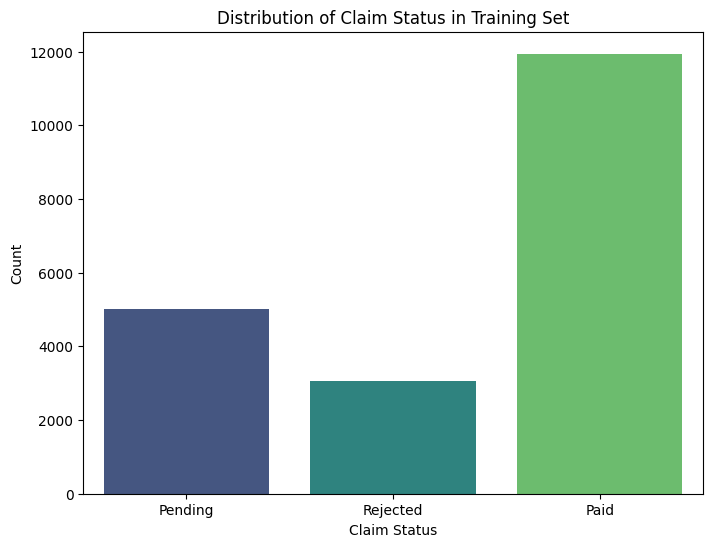

In [76]:
print("Value counts of 'claim_status' in the training set:")
print(train_y['claim_status'].value_counts())

plt.figure(figsize=(8, 6))
sns.countplot(data=train_y, x='claim_status', hue='claim_status', palette='viridis', legend=False)
plt.title('Distribution of Claim Status in Training Set')
plt.xlabel('Claim Status')
plt.ylabel('Count')
plt.show()

### Train baseline and advanced classification models.


In [77]:
from sklearn.preprocessing import LabelEncoder

# Encode the categorical target variable 'claim_status' into numerical format using `LabelEncoder` for both `train_y` and `test_y`.
# Instantiate LabelEncoder
le = LabelEncoder()

# Fit LabelEncoder to the full df_target to ensure all categories are learned
# This avoids errors if some categories are present in test_y but not train_y
le.fit(df_target['claim_status'])

# Transform the 'claim_status' column in train_y
train_y['claim_status_encoded'] = le.transform(train_y['claim_status'])

# Transform the 'claim_status' column in test_y
test_y['claim_status_encoded'] = le.transform(test_y['claim_status'])

# Display the head of the transformed train_y and test_y to verify the encoding
print("Head of transformed train_y:")
display(train_y.head())

print("Head of transformed test_y:")
display(test_y.head())

print("Mapping of encoded classes:")
for i, class_name in enumerate(le.classes_):
    print(f"{class_name}: {i}")

Head of transformed train_y:


,claim_status,claim_status_encoded
0,Pending,1
1,Rejected,2
2,Paid,0
3,Pending,1
4,Paid,0


Head of transformed test_y:


,claim_status,claim_status_encoded
20000,Paid,0
20001,Paid,0
20002,Paid,0
20003,Paid,0
20004,Paid,0


Mapping of encoded classes:
Paid: 0
Pending: 1
Rejected: 2


In [78]:
# Address any remaining missing values in the feature DataFrames (`train_X` and `test_x`),
# specifically for columns like 'approved_amount', 'payment_days', and 'avg_days_between_visits'.
# Identify columns with missing values in train_X
missing_cols_train = train_X.isnull().sum()
missing_cols_train = missing_cols_train[missing_cols_train > 0].index.tolist()
print(f"Columns with missing values in train_X: {missing_cols_train}")

# Identify columns with missing values in test_x
missing_cols_test = test_x.isnull().sum()
missing_cols_test = missing_cols_test[missing_cols_test > 0].index.tolist()
print(f"Columns with missing values in test_x: {missing_cols_test}")

# Columns to impute (based on common missing ones and potential for others)
impute_cols = list(set(missing_cols_train + missing_cols_test))

# Calculate medians from train_X for imputation
imputation_values = {}
for col in impute_cols:
    if col in train_X.columns and train_X[col].dtype in ['float64', 'int64']:
        median_val = train_X[col].median()
        imputation_values[col] = median_val
        # Fix for FutureWarning: Avoid chained assignment by direct assignment
        train_X.loc[:, col] = train_X[col].fillna(median_val)
        test_x.loc[:, col] = test_x[col].fillna(median_val)
print(f"Imputation values (medians from train_X): {imputation_values}")

# Remove 'patient_id' column
if 'patient_id' in train_X.columns:
    train_X = train_X.drop(columns=['patient_id'])
    print("Dropped 'patient_id' from train_X")
if 'patient_id' in test_x.columns:
    test_x = test_x.drop(columns=['patient_id'])
    print("Dropped 'patient_id' from test_x")

# Verify no remaining missing values and 'patient_id' is dropped
print("\nMissing values after imputation in train_X:\n", train_X.isnull().sum().sum())
print("\nMissing values after imputation in test_x:\n", test_x.isnull().sum().sum())
print("\n'patient_id' in train_X columns:", 'patient_id' in train_X.columns)
print("'patient_id' in test_x columns:", 'patient_id' in test_x.columns)

print("\nHead of train_X after processing:")
display(train_X.head())
print("\nHead of test_x after processing:")
display(test_x.head())

Columns with missing values in train_X: ['approved_amount', 'payment_days', 'amount_difference', 'approval_ratio', 'avg_days_between_visits']
Columns with missing values in test_x: ['approved_amount', 'payment_days', 'amount_difference', 'approval_ratio', 'avg_days_between_visits']
Imputation values (medians from train_X): {'approval_ratio': 1.0, 'approved_amount': 14379.99, 'amount_difference': 0.0, 'payment_days': 13.0, 'avg_days_between_visits': 50.833333333333336}
Dropped 'patient_id' from train_X
Dropped 'patient_id' from test_x

Missing values after imputation in train_X:
 0

Missing values after imputation in test_x:
 0

'patient_id' in train_X columns: False
'patient_id' in test_x columns: False

Head of train_X after processing:


,age,chronic_flag,billed_amount,approved_amount,payment_days,amount_difference,approval_ratio,days_between_visit_and_billing,length_of_stay_days,gender_M,...,insurance_provider_MediCareX,insurance_provider_SecureLife,department_ER,department_General,department_ICU,department_Neurology,department_Orthopedics,visit_type_ICU,visit_type_OPD,avg_days_between_visits
0,53,0,26555.09,26555.09,4.0,0.00,1.000000,325,0.815417,True,...,False,True,False,False,False,False,False,False,True,49.6
1,53,0,38801.14,38801.14,1.0,0.00,1.000000,84,0.317917,True,...,False,True,False,False,False,False,True,False,False,49.6
2,53,0,9049.72,9049.72,19.0,0.00,1.000000,0,1.252917,True,...,False,True,False,False,True,False,False,False,False,49.6
3,53,0,13258.56,0.00,3.0,13258.56,0.000000,0,1.630000,True,...,False,True,False,False,False,False,True,False,True,49.6
4,53,0,11583.16,8065.34,6.0,3517.82,0.696299,0,1.263333,True,...,False,True,False,False,False,True,False,False,False,49.6



Head of test_x after processing:


,age,chronic_flag,billed_amount,approved_amount,payment_days,amount_difference,approval_ratio,days_between_visit_and_billing,length_of_stay_days,gender_M,...,insurance_provider_MediCareX,insurance_provider_SecureLife,department_ER,department_General,department_ICU,department_Neurology,department_Orthopedics,visit_type_ICU,visit_type_OPD,avg_days_between_visits
20000,43,0,44408.40,44408.40,7.0,0.0,1.0,0,0.746667,True,...,False,True,False,False,False,False,True,False,True,92.000000
20001,43,0,47069.41,47069.41,5.0,0.0,1.0,24,0.535417,True,...,False,True,False,False,False,True,False,False,False,92.000000
20002,84,1,6080.81,6080.81,4.0,0.0,1.0,62,0.744167,False,...,False,False,False,True,False,False,False,False,True,49.285714
20003,84,1,33919.66,33919.66,16.0,0.0,1.0,0,0.245833,False,...,False,False,False,False,False,False,True,False,True,49.285714
20004,84,1,26258.60,26258.60,13.0,0.0,1.0,266,0.717083,False,...,False,False,False,False,False,True,False,False,True,49.285714


In [79]:
import warnings
warnings.filterwarnings('ignore')

# Utilizing SMOTE to address class imabalance and its mitigation
# Import SMOTE
from imblearn.over_sampling import SMOTE

# Instantiate SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE to the training data
X_resampled, y_resampled = smote.fit_resample(train_X, train_y['claim_status_encoded'])

# Display the value counts of the resampled target to show the new class distribution
print("Class distribution after SMOTE:")
print(y_resampled.value_counts())


Class distribution after SMOTE:
claim_status_encoded
1    11941
2    11941
0    11941
Name: count, dtype: int64


### Train baseline and advanced classification models.

#### Following models are used for training
* Logistic Regression
* Random Forest

#### To analyze result, following techniques are used:
* Classication Report
* Confusion Matrix


Logistic Regression model trained successfully on resampled data with balanced class weights.

Classification Report for Logistic Regression Model:
              precision    recall  f1-score   support

        Paid       0.65      0.61      0.63      2999
     Pending       0.23      0.15      0.18      1255
    Rejected       0.22      0.40      0.28       746

    accuracy                           0.46      5000
   macro avg       0.36      0.39      0.36      5000
weighted avg       0.48      0.46      0.46      5000



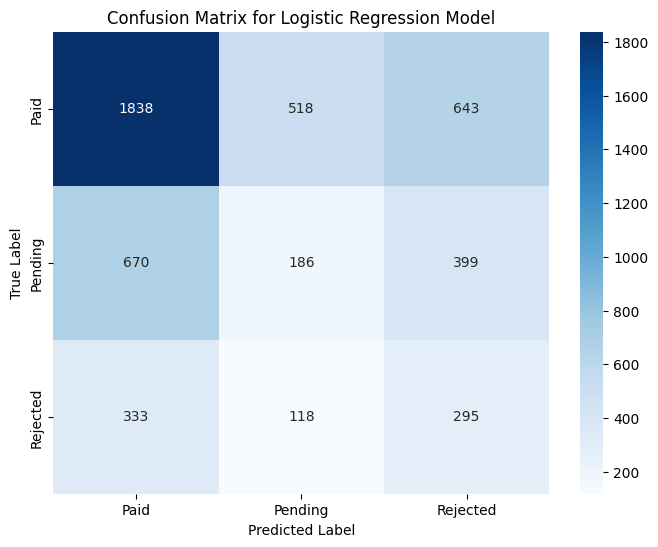

In [80]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Applying LogisticRegression


# Instantiate Logistic Regression model with class_weight='balanced'
log_reg_model = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')

# Fit the model to the resampled training data
log_reg_model.fit(X_resampled, y_resampled)

print("Logistic Regression model trained successfully on resampled data with balanced class weights.")

# Model Evaluation
# 1. Use the trained log_reg_model to make predictions on the test_x features
y_pred_log_reg = log_reg_model.predict(test_x)

# 2. Generate a classification report
print("\nClassification Report for Logistic Regression Model:")
print(classification_report(test_y['claim_status_encoded'], y_pred_log_reg, target_names=le.classes_))

# 3. Create a confusion matrix
cm_log_reg = confusion_matrix(test_y['claim_status_encoded'], y_pred_log_reg)

# 4. Display the confusion matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm_log_reg, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Logistic Regression Model')
plt.show()

## Train Advanced Model (Random Forest)

### Subtask:
Train a Random Forest Classifier on the balanced training data. Random Forest is an ensemble learning method known for its good performance and handling of various data types.


**Reasoning**:
To train an advanced model, I will instantiate and fit a RandomForestClassifier to the resampled training data as instructed in the subtask.



In [81]:
from sklearn.ensemble import RandomForestClassifier

# Instantiate a RandomForestClassifier object
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Fit the Random Forest model to the resampled training data
rf_model.fit(X_resampled, y_resampled)

print("Random Forest Classifier trained successfully on resampled data.")

Random Forest Classifier trained successfully on resampled data.


**Reasoning**:
Now that the Random Forest model has been trained, the next step is to evaluate its performance on the test data. This involves making predictions, generating a classification report, and visualizing the confusion matrix to assess its accuracy, precision, recall, and F1-score for each class.




Classification Report for Random Forest Model:
              precision    recall  f1-score   support

        Paid       0.64      0.78      0.70      2999
     Pending       0.39      0.26      0.31      1255
    Rejected       0.31      0.21      0.25       746

    accuracy                           0.56      5000
   macro avg       0.45      0.42      0.42      5000
weighted avg       0.53      0.56      0.54      5000



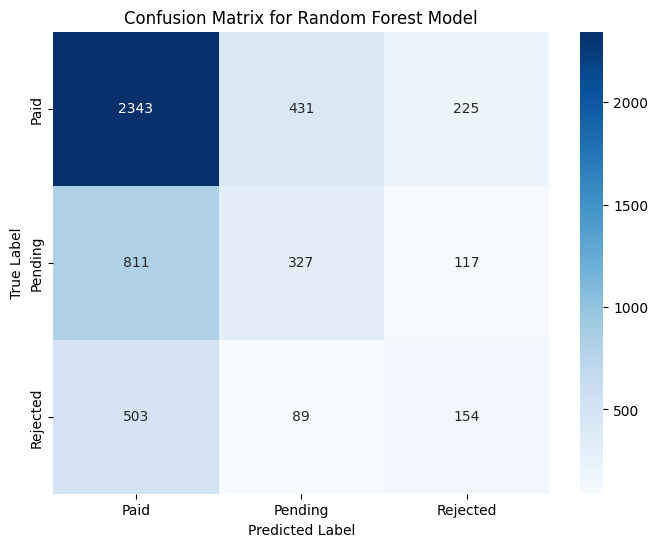

In [82]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Make predictions on the test data using the trained Random Forest model
y_pred_rf = rf_model.predict(test_x)

# Generate a classification report
print("\nClassification Report for Random Forest Model:")
print(classification_report(test_y['claim_status_encoded'], y_pred_rf, target_names=le.classes_))

# Create a confusion matrix
cm_rf = confusion_matrix(test_y['claim_status_encoded'], y_pred_rf)

# Display the confusion matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Random Forest Model')
plt.show()

## Summary:

### Q&A
*   **Class Imbalance Analysis and Mitigation:** The `claim_status` target variable in the training set exhibited significant class imbalance, with 'Paid' claims (11,941 instances) being the majority class, followed by 'Pending' (5,008 instances) and 'Rejected' (3,051 instances). To address this, SMOTE (Synthetic Minority Over-sampling Technique) was applied to the training data. This successfully balanced the classes, resulting in an equal distribution of 11,941 instances for each of the 'Paid', 'Pending', and 'Rejected' categories.
*   **Model Performance:**
    *   **Logistic Regression:** Achieved an overall accuracy of 46% on the test set. It performed best for the 'Paid' class (F1-score: 0.63) but struggled significantly with 'Pending' (F1-score: 0.18) and 'Rejected' (F1-score: 0.28) classes.
    *   **Random Forest:** Achieved a higher overall accuracy of 56% on the test set. Similar to Logistic Regression, it performed best for the 'Paid' class (F1-score: 0.70) but also struggled with 'Pending' (F1-score: 0.23) and 'Rejected' (F1-score: 0.25) classes.
*   **Which model performed better and why:** The **Random Forest model performed better** than the Logistic Regression model, achieving a higher overall accuracy (56% vs. 46%). Random Forest, as an ensemble method, typically captures more complex, non-linear relationships in data than linear models like Logistic Regression, leading to its superior performance on this dataset. However, both models still struggled significantly with the minority classes ('Pending' and 'Rejected'), indicating that while SMOTE balanced the training data, the inherent difficulty in distinguishing these classes persists.
*   **Potential Next Steps:**
    *   Further hyperparameter tuning for the Random Forest model and exploration of other advanced ensemble techniques or different sampling strategies to improve minority class prediction.
    *   Feature engineering to create more distinctive features that could help differentiate between 'Pending' and 'Rejected' claims.
    *   Consider alternative evaluation metrics or cost-sensitive learning if specific misclassification costs are associated with 'Pending' or 'Rejected' claims.

### Data Analysis Key Findings
*   **Initial Class Imbalance:** The `claim_status` target variable in the training set exhibited significant class imbalance: 'Paid' claims accounted for 11,941 instances, 'Pending' for 5,008, and 'Rejected' for 3,051.
*   **Target Variable Encoding:** The categorical `claim_status` was successfully encoded into numerical format, mapping 'Paid' to 0, 'Pending' to 1, and 'Rejected' to 2.
*   **Missing Value Handling:** Missing values in numerical features such as `approved_amount`, `payment_days`, `amount_difference`, `approval_ratio`, and `avg_days_between_visits` were imputed using median values calculated from the training set. The `patient_id` column was removed from both training and testing feature sets.
*   **Class Imbalance Mitigation:** SMOTE effectively balanced the training data, resulting in an equal distribution of 11,941 samples for each of the three `claim_status` classes.
*   **Logistic Regression Performance:** The baseline Logistic Regression model achieved an overall accuracy of 46% on the test set. While performing relatively well for 'Paid' claims (F1-score: 0.63), its performance was poor for 'Pending' (F1-score: 0.18) and 'Rejected' (F1-score: 0.28) claims.
*   **Random Forest Performance:** The Random Forest model achieved a higher overall accuracy of 56% on the test set. It also performed best on 'Paid' claims (F1-score: 0.70) but continued to struggle with 'Pending' (F1-score: 0.23) and 'Rejected' (F1-score: 0.25) claims.

### Insights or Next Steps
*   Despite applying SMOTE, both models demonstrate significant difficulty in accurately classifying the minority 'Pending' and 'Rejected' claim statuses, suggesting that balancing the dataset alone might not be sufficient due to inherent data complexity or feature limitations.
*   To improve performance, especially for critical minority classes, future steps should focus on advanced feature engineering, exploring more sophisticated ensemble models, or implementing cost-sensitive learning approaches that penalize misclassifications of 'Pending' and 'Rejected' claims more heavily.
